# Setup & Load Data





In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
df = pd.read_csv('gsearch_jobs.csv', on_bad_lines='skip', engine='python')

In [ ]:
print(df.shape)

(6808, 27)


In [ ]:
df.head()

,Unnamed: 0,index,title,company_name,location,via,description,extensions,job_id,thumbnail,...,commute_time,salary_pay,salary_rate,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens
0,0,0,Data Analyst,Meta,Anywhere,via LinkedIn,In the intersection of compliance and analytic...,"['15 hours ago', '101K–143K a year', 'Work fro...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,101K–143K,a year,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"['tableau', 'r', 'python', 'sql']"
1,1,1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,"['12 hours ago', 'Full-time', 'Health insurance']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
2,2,2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,"['18 hours ago', 'Full-time']",eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql']
3,3,3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,via Upwork,Enthusiastic Data Analyst for processing sales...,"['12 hours ago', '15–25 an hour', 'Work from h...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgLSBDb25zdW...,NaN,...,NaN,15–25,an hour,20.0,15.0,25.0,20.0,NaN,41600.0,"['powerpoint', 'excel', 'power_bi']"
4,4,4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,"['7 hours ago', '90K–110K a year', 'Contractor']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgfCBXb3JrZm...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,90K–110K,a year,100000.0,90000.0,110000.0,NaN,100000.0,100000.0,"['powerpoint', 'excel', 'outlook', 'word']"


In [ ]:
#Drop any duplicates in data
df = df.drop_duplicates(subset=["job_id"]).reset_index(drop=True)

In [ ]:
# only using relevant columns
keep_cols = ["job_id", "title", "company_name", "location", "description", "salary_standardized", "search_term"]
df = df[keep_cols].copy()

In [ ]:
# seeing how many NA values there are in the dataset
df.isna().sum()

,0
job_id,0
title,0
company_name,0
location,0
description,0
salary_standardized,4830
search_term,0


*NOTE*: The high percentage of missing salary (83.5%) suggests limited transparency in compensation reporting, which may itself contribute to inequities in hiring. If we choose to look into the effect of gender bias on pay

*NOTE*: The dataset contains 57,775 job postings (non-duplicate). Salary information should probably only be treated as an optional exploratory rather than be central to the study

#Text Cleaning

In [ ]:
def clean_text(text: str) -> str:
  # lowercase
  text = str(text).lower()
  # removing unwanted/unusual characters
  text = re.sub(r"<br\s*/?>", " ", text)
  # remove urls
  text = re.sub(r"http\S+|www\.\S+", " ", text)
  # remove non-ascii characters
  text = text.encode("ascii", "ignore").decode()
  # remove digits
  text = re.sub(r"\d+", " ", text)
  # only lowercase and spaces
  text = re.sub(r"[^a-z\s]", " ", text)
  # replace all long whitespace with a single space
  text = re.sub(r"\s+", " ", text).strip()
  return text

In [ ]:
df['clean_desc'] = df['description'].apply(clean_text)

In [ ]:
df[['description', 'clean_desc']].head(10)

,description,clean_desc
0,In the intersection of compliance and analytic...,in the intersection of compliance and analytic...
1,Job Title: Entry Level Business Analyst / Prod...,job title entry level business analyst product...
2,Overview:\n\nWe are seeking a full-time...\nAe...,overview we are seeking a full time aeronautic...
3,Enthusiastic Data Analyst for processing sales...,enthusiastic data analyst for processing sales...
4,Overview of Position\n\nThis position will be ...,overview of position this position will be the...
5,Your Job\n\nFlint Hills Resources is seeking a...,your job flint hills resources is seeking a da...
6,"Are you passionate about Credit Risk, Data Ana...",are you passionate about credit risk data anal...
7,"In order to be considered for this role, after...",in order to be considered for this role after ...
8,"This a Full Remote job, the offer is available...",this a full remote job the offer is available ...
9,Job Summary: The Data Analyst oversees data pr...,job summary the data analyst oversees data pro...


#Create Labels using a lexicon

In [ ]:
masc_words = {
    "active",
    "adventurous",
    "aggress",        # aggressive, aggression
    "ambitio",        # ambitious
    "assert",         # assertive
    "athletic",
    "autonom",        # autonomous
    "boast",
    "challeng",       # challenge
    "compet",         # competitive
    "confident",
    "courag",         # courage, courageous
    "decide",
    "decisive",
    "decision",
    "determin",       # determined
    "dominant",
    "domina",         # domination
    "force",
    "greedy",
    "headstrong",
    "hierarch",       # hierarchical
    "hostil",         # hostile
    "impuls",         # impulsive
    "independen",     # independent
    "individual",
    "intellect",      # intellectual
    "leader",
    "logic",
    "masculine",
    "objective",
    "opinion",
    "outspoken",
    "persist",        # persistent
    "principle",
    "reckless",
    "stubborn",
    "superior",
    "self confiden",  # self-confident
}

In [ ]:
agency_words = {
"accomplish","accurac","accurate","adaptab","adept",
"ambition","ambitious","aptitude","aspiration","aspire","aspiring",
"assert","attain","authoritative","autonomous","autonomy","capab",
"clever","compet","confident","conscientious",
"decid","decision","decisive",
"determin",
"effective","efficien","effort","empowered",
"expert","fluen",
"independ","individualist",
"intent","intuitive",
"keen","logic",
"masterful","mastery",
"motivat",
"objectiv",
"persever","persist","persistent",
"pioneer","pragmat","prevail",
"priorit","proactive",
"productive","productivity","proficien",
"prosper","proud",
"purpose","pursu",
"rational","realiz",
"recog","reliab","reputation",
"resilien","resolute","resolv",
"responsib",
"reward","risk",
"savv",
"smart","steadfast",
"strive","striving","struggl",
"stubborn",
"succeed","success",
"tenac",
"triumph",
"unyielding",
"victor",
"willpower",
"win","winner","winning",
"wit"
}

In [ ]:
fem_words = {
    "affectionate",
    "child",
    "cheer",
    "commit",
    "communal",
    "compassion",
    "connect",
    "considerate",
    "cooperat",       # cooperative
    "depend",         # dependable
    "emotion",        # emotional
    "empath",         # empathetic
    "feminine",
    "flatterable",
    "gentle",
    "honest",
    "interpersonal",
    "interdependen",  # interdependent
    "kind",
    "kinship",
    "loyal",
    "modesty",
    "nag",
    "nurtur",         # nurture
    "pleasant",
    "polite",
    "quiet",
    "responsible",
    "sensitiv",       # sensitive
    "submissive",
    "supporting",
    "sympath",        # sympathetic
    "tender",
    "together",
    "trust",
    "understanding",
    "warm",
    "whin",           # whine
    "yield"
}

In [ ]:
communion_words = {
"affection","affiliat","altruis",
"amenab","amiab","amicab",
"appreciat","assist","benevolen",
"care","caring",
"charit",
"closeness",
"collab","colleague","collective",
"commun",
"companion","compassion",
"considerate","cooperat",
"counsel","courteous",
"dialogue","discuss",
"empath",
"equitab",
"familial","family",
"friend",
"generos","generous","grateful",
"gregarious",
"guidanc",
"harmon",
"help",
"honest",
"hospitab","hospitality",
"human",
"impartial",
"interpersonal",
"kindly","kindness",
"kinship",
"learn",
"love","loving",
"loyal",
"magnanimous",
"mutual",
"neighbor",
"nurtur",
"open mind",
"participat",
"partner",
"philanth",
"polite",
"recipr",
"reconcil",
"relationship",
"respect",
"sacrific",
"selfless",
"servic",
"share","sharing",
"sincer",
"socia","societ",
"solidarity",
"suggest",
"support",
"sympath",
"teach",
"together",
"tradition",
"trust",
"unity",
"unselfish",
"volunt",
"welcom",
"welfare",
"inclusiv"
}

In [ ]:
masc_words = masc_words | agency_words
fem_words = fem_words | communion_words

In [ ]:
# function to count the amount of feminine and masculine hits in the descriptions
def count_lexicon_hits(text, lexicon):
    hits = 0
    for stem in lexicon:
        pattern = r"\b" + re.escape(stem) + r"\w*"
        hits += len(re.findall(pattern, text))
    return hits

In [ ]:
df["masc_hits"] = df["clean_desc"].apply(lambda x: count_lexicon_hits(x, masc_words))
df["fem_hits"]  = df["clean_desc"].apply(lambda x: count_lexicon_hits(x, fem_words))

In [ ]:
# for each description, label it as masculine, femenine, or neutral based on the number of hits from the previous function
def label_gender_code(m, f):
    if m > f and m >= 1:
        return "masculine"
    elif f > m and f >= 1:
        return "feminine"
    else:
        return "neutral"

In [ ]:
df["label"] = df.apply(lambda r: label_gender_code(r["masc_hits"], r["fem_hits"]), axis=1)

In [ ]:
df["label"].value_counts(normalize=True).round(3), df["label"].value_counts()

(label
 masculine    0.739
 feminine     0.202
 neutral      0.059
 Name: proportion, dtype: float64,
 label
 masculine    4073
 feminine     1116
 neutral       325
 Name: count, dtype: int64)

In [ ]:
df.groupby("label")[["masc_hits","fem_hits"]].mean()

,masc_hits,fem_hits
label,,
feminine,15.993728,21.733871
masculine,19.159833,11.629266
neutral,8.495385,8.495385


#Train Baseline Model

In [ ]:
X_vector = df['clean_desc']
y_data = df['label']

X_train, X_test, y_train, y_test = train_test_split(X_vector, y_data, test_size=0.2, random_state=1, stratify=y_data)

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [ ]:
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# testing with all the test data
y_pred = logistic_model.predict(X_test_tfidf)

# Feature Importance

In [ ]:
# Analyzing feature imoprtance for the logistic regressoin model
feature_names = tfidf_vectorizer.get_feature_names_out()
coefs = logistic_model.coef_

In [ ]:
# Get the classes from the model
classes = logistic_model.classes_

for i, class_label in enumerate(classes):
    print(f"\nTop features for class: {class_label}")
    # Sort coefficients for the current class in descending order
    sorted_coef_indices = coefs[i].argsort()[::-1]

    # Display top 10 positive coefficients
    print(f"  Most positive:")
    for j in sorted_coef_indices[:10]:
        print(f"    {feature_names[j]}: {coefs[i][j]:.4f}")

    # Display top 10 negative coefficients
    print(f"  Most negative:")
    for j in sorted_coef_indices[-10:]: # Get the last 10 for most negative
        print(f"    {feature_names[j]}: {coefs[i][j]:.4f}")


Top features for class: feminine
  Most positive:
    support: 3.5411
    supporting: 3.0072
    services: 2.4282
    learning: 2.3850
    social: 2.1332
    care: 1.9625
    help: 1.9426
    service: 1.7698
    understanding: 1.7686
    community: 1.6171
  Most negative:
    experience: -1.1033
    accuracy: -1.1422
    leadership: -1.1436
    competitive: -1.1673
    responsibilities: -1.2365
    risk: -1.2619
    objectives: -1.2702
    proficiency: -1.4081
    effectively: -1.4413
    expertise: -1.8538

Top features for class: masculine
  Most positive:
    risk: 1.9929
    expertise: 1.8985
    experience: 1.8983
    proficiency: 1.8769
    responsibilities: 1.8024
    ability: 1.6314
    objectives: 1.5946
    effectively: 1.5885
    leadership: 1.5693
    ensure: 1.4609
  Most negative:
    learn: -1.5884
    help: -1.6727
    understanding: -1.7259
    social: -1.9474
    service: -1.9956
    learning: -2.0309
    services: -2.1537
    care: -2.3680
    supporting: -3.1709
  

#Evaluate Model

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test, y_pred)

0.8295557570262919

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

    feminine       0.89      0.49      0.63       223
   masculine       0.82      0.99      0.90       815
     neutral       1.00      0.03      0.06        65

    accuracy                           0.83      1103
   macro avg       0.90      0.50      0.53      1103
weighted avg       0.85      0.83      0.79      1103

[[110 113   0]
 [ 12 803   0]
 [  2  61   2]]


In [ ]:
import pickle

# Save the trained model to a file
with open('gender_prediction_model.pkl', 'wb') as file:
    pickle.dump(logistic_model, file)

print("Model saved as gender_prediction_model.pkl")

Model saved as gender_prediction_model.pkl


In [ ]:
sample_posting = "We’re looking for a thoughtful, driven individual who wants to learn, grow, and solve hard problems. This role requires extensive use of data analytics to derive insights and develop credit strategies"

In [ ]:
processed_text = clean_text(sample_posting)

In [ ]:
# match vector size
sample_tfidf = tfidf_vectorizer.transform([processed_text])
gender_prediction = logistic_model.predict(sample_tfidf)
print(gender_prediction)

['masculine']


In [ ]:
sample_2 = ("We are looking for a thoughtful and supportive Data Analyst who enjoys working closely with others to help teams better understand and use their data.
  In this role, you will collaborate with colleagues across the organization to provide insights that support decision-making and improve services for our customers.
  The ideal candidate values teamwork, communication, and collaboration, and enjoys helping others interpret and apply data in meaningful ways. You will work with
  cross-functional teams to share insights, assist with reporting needs, and support departments in understanding key trends and patterns.")

processed_text = clean_text(sample_2)
sample_tfidf = tfidf_vectorizer.transform([processed_text])
gender_prediction = logistic_model.predict(sample_tfidf)
print(gender_prediction)

['feminine']


# Graphs

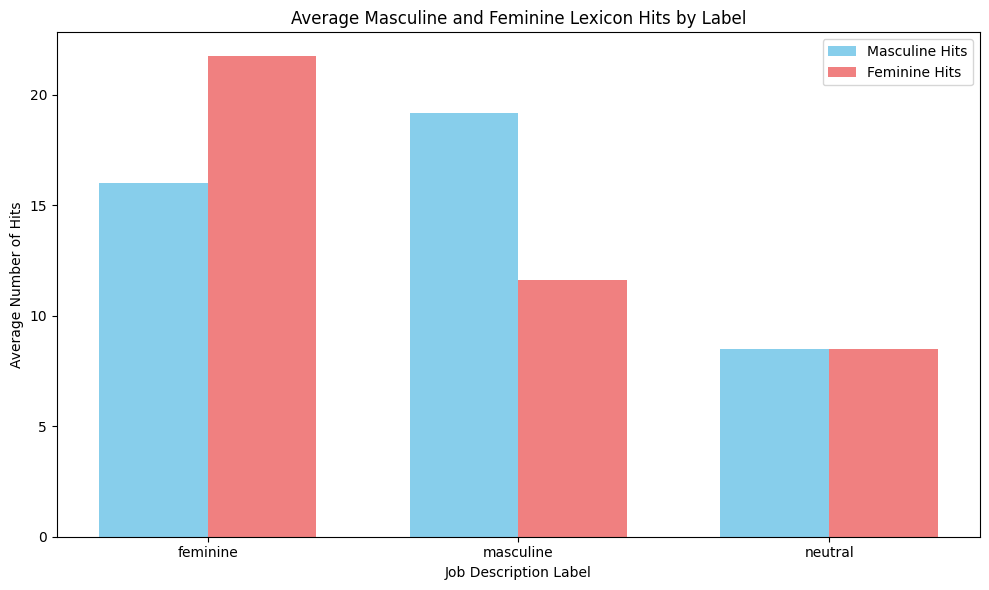

In [ ]:
import matplotlib.pyplot as plt

grouped_hits = df.groupby("label")[["masc_hits","fem_hits"]].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

labels = grouped_hits['label']
x = range(len(labels))
width = 0.35

# Plotting masculine hits
rects1 = ax.bar([i - width/2 for i in x], grouped_hits['masc_hits'], width, label='Masculine Hits', color='skyblue')
# Plotting feminine hits
rects2 = ax.bar([i + width/2 for i in x], grouped_hits['fem_hits'], width, label='Feminine Hits', color='lightcoral')

ax.set_title('Average Masculine and Feminine Lexicon Hits by Label')
ax.set_xlabel('Job Description Label')
ax.set_ylabel('Average Number of Hits')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()

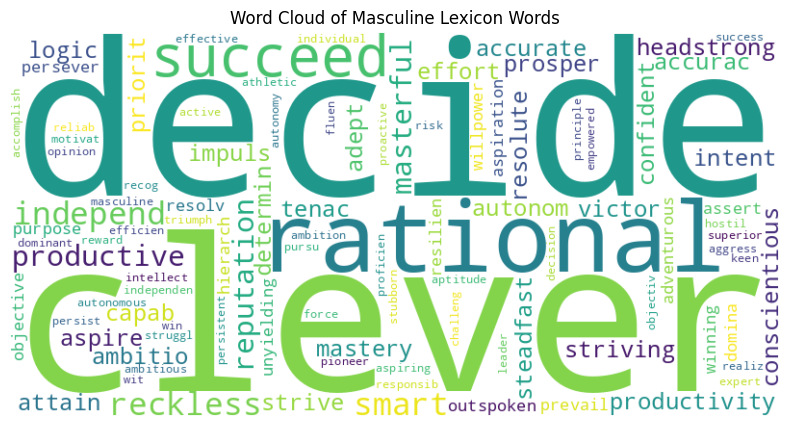

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all masculine lexicon words into a single string
masc_lexicon_text = ' '.join(list(masc_words))

# Generate word cloud from the masculine lexicon
wordcloud_lexicon = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='viridis'
).generate(masc_lexicon_text)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_lexicon, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Masculine Lexicon Words')
plt.show()

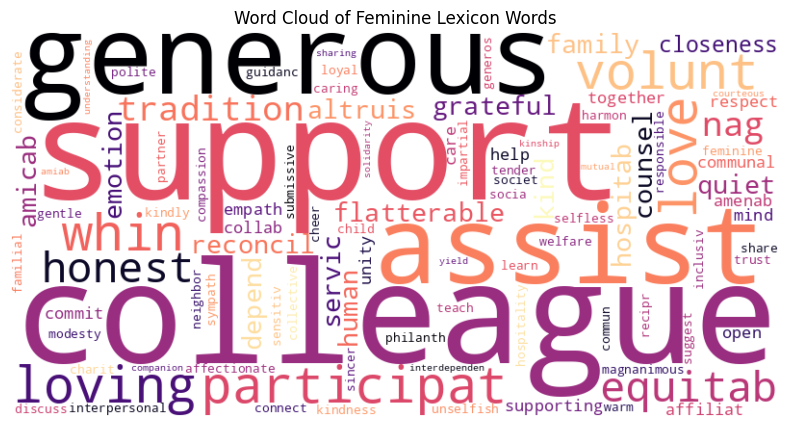

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all feminine lexicon words into a single string
fem_lexicon_text = ' '.join(list(fem_words))

# Generate word cloud from the feminine lexicon
wordcloud_lexicon = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='magma'
).generate(fem_lexicon_text)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_lexicon, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Feminine Lexicon Words')
plt.show()

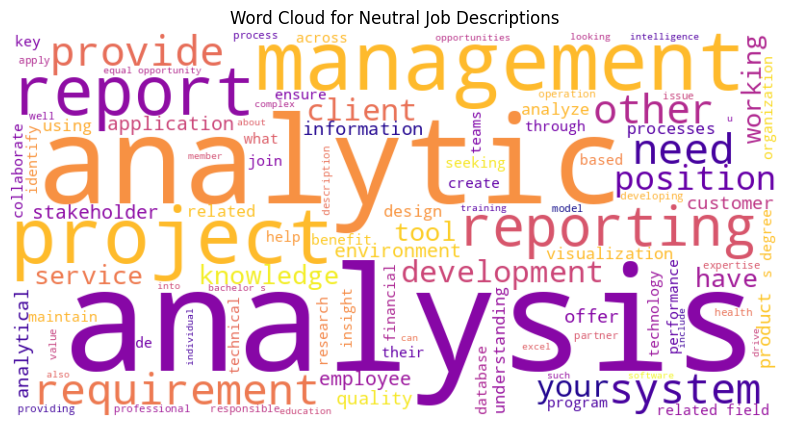

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter for neutral descriptions
neutral_df = df[df['label'] == 'neutral']

# Combine all neutral descriptions into a single string
neutral_text = ' '.join(neutral_df['clean_desc'].dropna())

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='plasma',
    stopwords=set(['job', 'data', 'analyst', 'experience', 'work', 'ability', 'business', 'develop', 'new', 'team', 'company', 'e', 'will', 'skills', 'required', 'strong', 'manage', 'solutions', 'role', 'including', 'years', 'responsibilities', 'support', 'with', 'and', 'the', 'for', 'of', 'to', 'a', 'in', 'is', 'on', 'as', 'by', 'be', 'it', 'from', 'or', 'we', 'at', 'this', 'you', 'are', 'an', 'that', 'our', 'all', 'etc'])
).generate(neutral_text)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Neutral Job Descriptions')
plt.show()

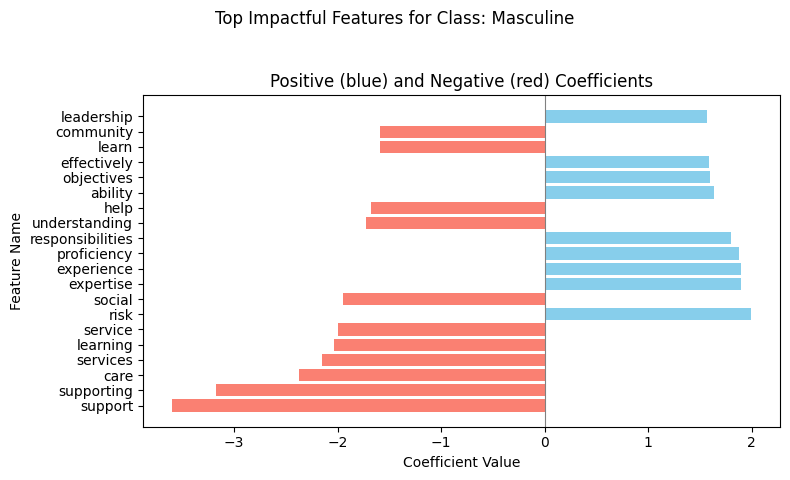

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Find the index for the 'masculine' class
masculine_class_index = np.where(logistic_model.classes_ == 'masculine')[0][0]

# Get coefficients for the masculine class
masculine_coefs = coefs[masculine_class_index]

# Sort coefficients by absolute value in descending order
abs_sorted_coef_indices = np.argsort(np.abs(masculine_coefs))[::-1]

# Get the top 20 most impactful features
top_impactful_indices = abs_sorted_coef_indices[:20]
top_impactful_features = [feature_names[j] for j in top_impactful_indices]
top_impactful_coefs = [masculine_coefs[j] for j in top_impactful_indices]

# Create a single plot for the masculine class
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('Top Impactful Features for Class: Masculine', fontsize=12)

# Use different colors for positive and negative coefficients
colors = ['skyblue' if c > 0 else 'salmon' for c in top_impactful_coefs]

# Plot all impactful features on one bar chart
ax.barh(top_impactful_features[::-1], top_impactful_coefs[::-1], color=colors[::-1])
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Feature Name')
ax.set_title('Positive (blue) and Negative (red) Coefficients')

# Add a vertical line at 0 for better readability
ax.axvline(0, color='grey', linewidth=0.8)
ax.invert_yaxis() # Invert y-axis to have the largest coefficient at the top

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

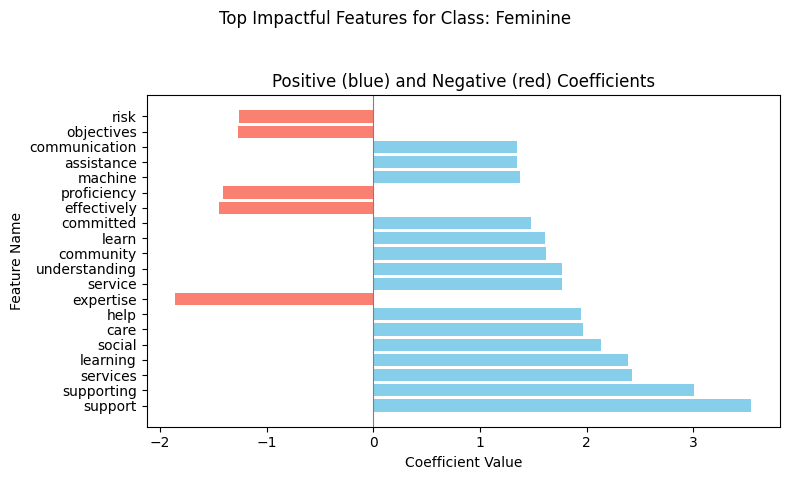

In [ ]:
# Find the index for the 'feminine' class
feminine_class_index = np.where(logistic_model.classes_ == 'feminine')[0][0]

# Get coefficients for the feminine class
feminine_coefs = coefs[feminine_class_index]

# Sort coefficients by absolute value in descending order
abs_sorted_coef_indices = np.argsort(np.abs(feminine_coefs))[::-1]

# Get the top 20 most impactful features
top_impactful_indices = abs_sorted_coef_indices[:20]
top_impactful_features = [feature_names[j] for j in top_impactful_indices]
top_impactful_coefs = [feminine_coefs[j] for j in top_impactful_indices]

# Create a single plot for the feminine class
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('Top Impactful Features for Class: Feminine', fontsize=12)

# Use different colors for positive and negative coefficients
colors = ['skyblue' if c > 0 else 'salmon' for c in top_impactful_coefs]

# Plot all impactful features on one bar chart
ax.barh(top_impactful_features[::-1], top_impactful_coefs[::-1], color=colors[::-1])
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Feature Name')
ax.set_title('Positive (blue) and Negative (red) Coefficients')

# Add a vertical line at 0 for better readability
ax.axvline(0, color='grey', linewidth=0.8)
ax.invert_yaxis() # Invert y-axis to have the largest coefficient at the top

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()